# GMM_codes.ipynb — 图形与模拟数据素材工厂

**用途**：生成 `GMM_lec.qmd` 讲义所需的全部图形（fig01–fig05），以及三个案例 notebook 所需的模拟数据（data01–data04）。

**输出路径**：
- 图形：`./figs/method_GMM_fig0N_xxx.png`（300 dpi，宽度 ≥ 1200px）
- 数据：`./data/method_GMM_data0N_xxx.csv`

**对应讲义章节**：
| 图形文件 | 对应章节 | 说明 |
|:--------|:--------|:-----|
| fig01_flowchart | 导言、第10节 | GMM 总流程图 |
| fig02_moment_conditions | 第2节 | 恰好识别 vs. 过度识别 |
| fig03_gmm_objective | 第3节 | 目标函数与权重矩阵 |
| fig04_efficiency | 第6节 | 蒙特卡洛分布对比 |
| fig05_2sls_vs_gmm | 第4节 | 权重机制差异示意图 |

In [1]:
# ── 导入库与全局设置 ─────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from scipy import stats
from scipy.optimize import minimize
import os, warnings
warnings.filterwarnings('ignore')

# ── 字体检测（与 MLE_codes 完全一致）────────────────────
import matplotlib.font_manager as fm
available = [f.name for f in fm.fontManager.ttflist]
CN_FONTS = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'Hiragino Sans GB',
            'Noto Sans CJK SC', 'WenQuanYi Micro Hei', 'Source Han Sans SC']
cn_font = next((f for f in CN_FONTS if f in available), None)
if cn_font:
    plt.rcParams['font.family'] = [cn_font, 'DejaVu Sans']
    print(f'中文字体：{cn_font}')
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
    print('未找到中文字体，使用 DejaVu Sans（中文可能显示为方块）')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

# ── 颜色方案（与 MLE_codes 完全一致）────────────────────
COLOR_PRIMARY   = '#2C6BAC'   # 主色：蓝色
COLOR_SECONDARY = '#E8A020'   # 辅色：橙黄色
COLOR_NEUTRAL   = '#888888'   # 中性：灰色
COLOR_FILL      = '#D6E8F7'   # 填充：淡蓝
COLOR_GREEN     = '#2CA02C'   # 绿色
COLOR_RED       = '#D62728'   # 红色
COLOR_BG        = '#F8F9FA'   # 背景浅灰

# ── 创建输出目录 ─────────────────────────────────────────
os.makedirs('./figs', exist_ok=True)
os.makedirs('./data', exist_ok=True)
print('输出目录已就绪：./figs/  ./data/')

中文字体：SimHei
输出目录已就绪：./figs/  ./data/


---
## Section 1：fig01 — GMM 总流程图

> 本图展示 GMM 的完整分析链条，是本章的「导航图」。与 MLE_fig01 风格保持一致（横向流程图，FancyBboxPatch，6个节点），但节点内容体现 GMM 的特点。
>
> **对应讲义**：导言、第 10 节（小结）

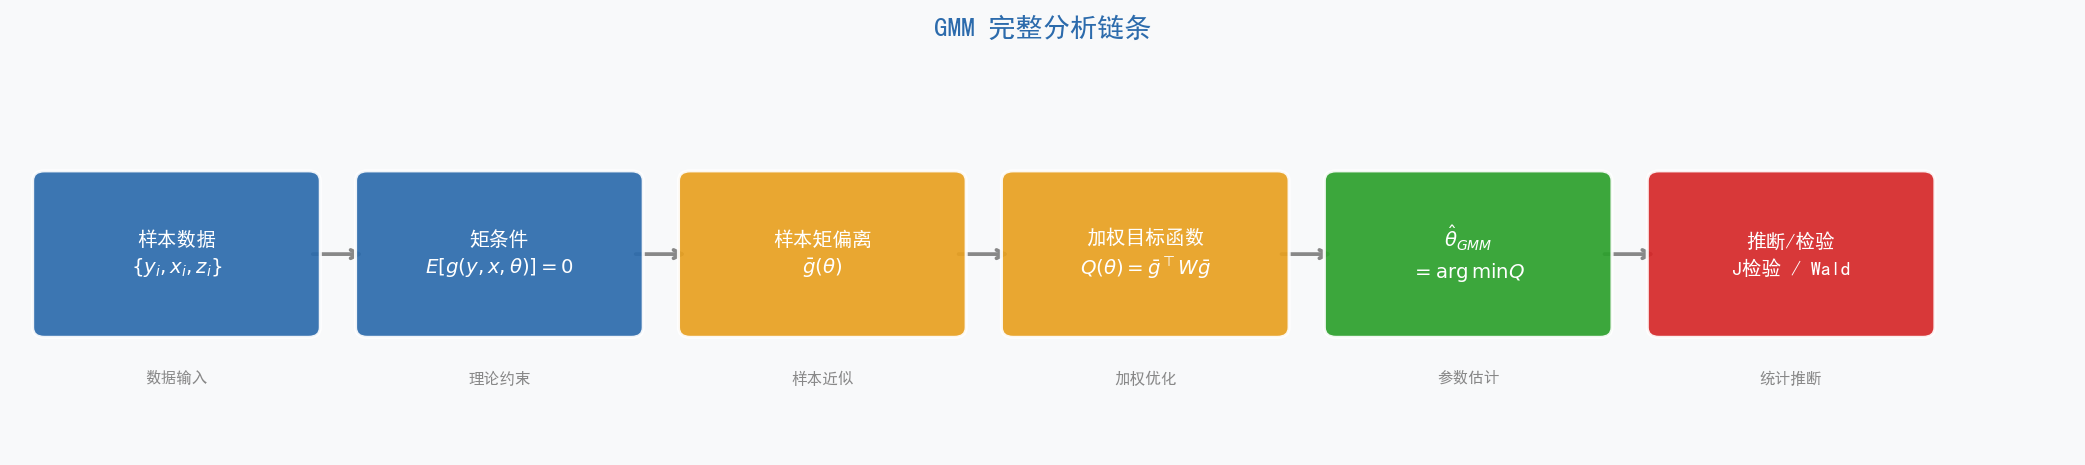

fig01 已保存


In [2]:
fig, ax = plt.subplots(figsize=(14, 3.2))
ax.set_xlim(0, 14)
ax.set_ylim(0, 3.2)
ax.axis('off')
fig.patch.set_facecolor(COLOR_BG)
ax.set_facecolor(COLOR_BG)

# 节点定义
nodes = [
    (1.1,  r'样本数据' + '\n' + r'$\{y_i, x_i, z_i\}$'),
    (3.3,  r'矩条件' + '\n' + r'$E[g(y,x,\theta)]=0$'),
    (5.5,  r'样本矩偏离' + '\n' + r'$\bar{g}(\theta)$'),
    (7.7,  r'加权目标函数' + '\n' + r'$Q(\theta)=\bar{g}^\top W\bar{g}$'),
    (9.9,  r'$\hat{\theta}_{GMM}$' + '\n' + r'$=\arg\min Q$'),
    (12.1, r'推断/检验' + '\n' + r'J检验 / Wald'),
]

box_w, box_h = 1.8, 1.2
colors_node = [COLOR_PRIMARY, COLOR_PRIMARY, COLOR_SECONDARY,
               COLOR_SECONDARY, COLOR_GREEN, COLOR_RED]

for i, (cx, label) in enumerate(nodes):
    x0 = cx - box_w / 2
    y0 = 1.0
    box = FancyBboxPatch((x0, y0), box_w, box_h,
                         boxstyle='round,pad=0.08',
                         linewidth=1.5,
                         edgecolor='white',
                         facecolor=colors_node[i],
                         alpha=0.92, zorder=3)
    ax.add_patch(box)
    ax.text(cx, 1.0 + box_h / 2, label,
            ha='center', va='center', color='white',
            fontsize=9.5, fontweight='bold', zorder=4,
            linespacing=1.5)

# 箭头
for i in range(len(nodes) - 1):
    x_start = nodes[i][0] + box_w / 2
    x_end   = nodes[i+1][0] - box_w / 2
    ax.annotate('', xy=(x_end, 1.6), xytext=(x_start, 1.6),
                arrowprops=dict(arrowstyle='->', color=COLOR_NEUTRAL,
                                lw=1.8), zorder=2)

# 标签
step_labels = ['数据输入', '理论约束', '样本近似', '加权优化', '参数估计', '统计推断']
for i, (cx, _) in enumerate(nodes):
    ax.text(cx, 0.65, step_labels[i], ha='center', va='top',
            fontsize=7.5, color=COLOR_NEUTRAL, style='italic')

ax.set_title('GMM 完整分析链条', fontsize=13, fontweight='bold',
             color=COLOR_PRIMARY, pad=10)

plt.tight_layout()
plt.savefig('./figs/method_GMM_fig01_flowchart.png', dpi=300, bbox_inches='tight',
            facecolor=COLOR_BG)
plt.show()
print('fig01 已保存')

---
## Section 2：fig02 — 矩条件示意图（恰好识别 vs. 过度识别）

> 本图用于第 2 节。左图展示单个矩条件（恰好识别）下，令 $\bar{g}(\hat{\theta})=0$ 精确找到估计量；右图展示三个矩条件（过度识别）下，矩条件之间存在冲突，只能找到使加权偏离最小的点。
>
> **对应讲义**：第 2 节「矩条件——GMM 的语言」

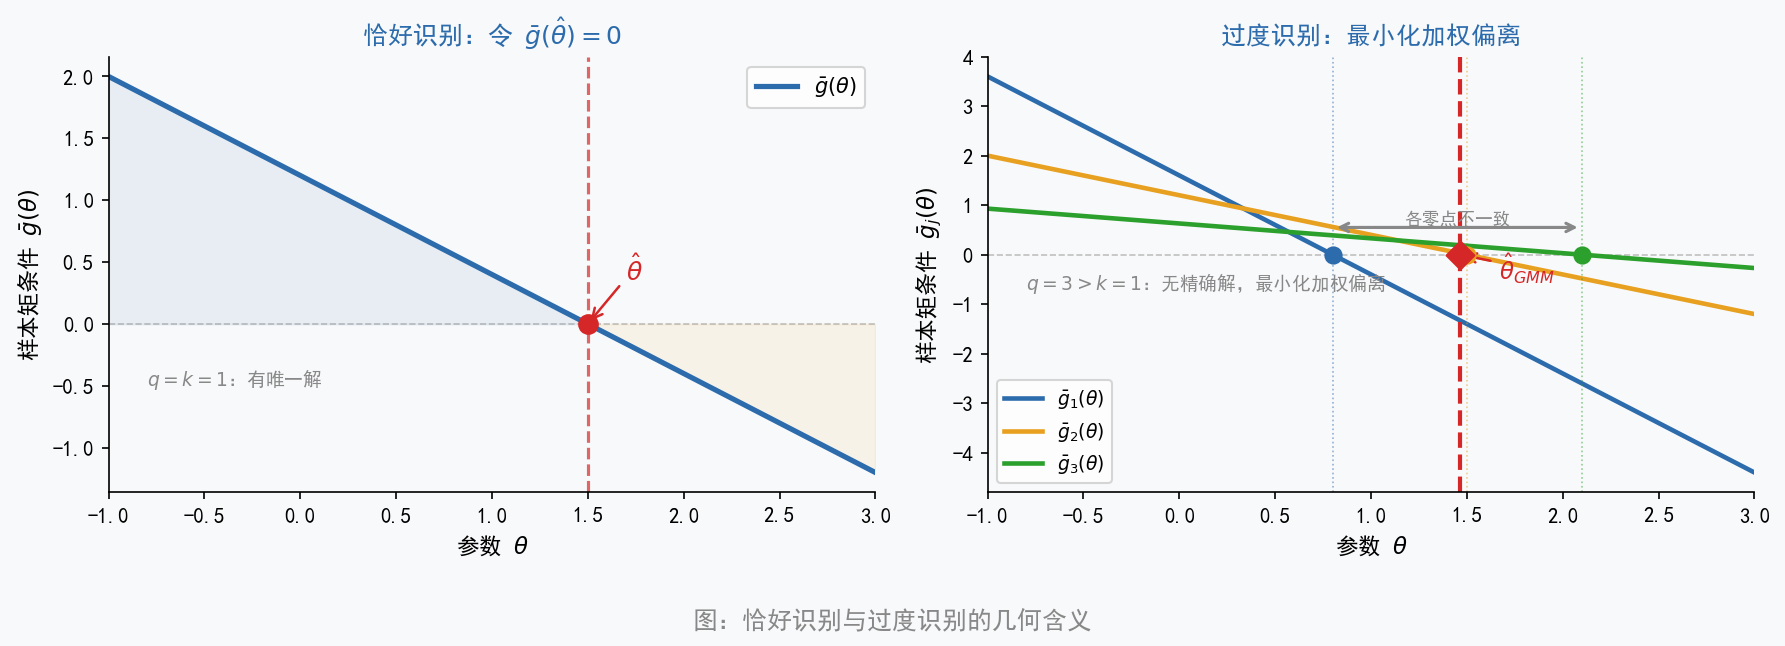

fig02 已保存


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.patch.set_facecolor(COLOR_BG)

theta = np.linspace(-1, 3, 300)

# ── 左图：恰好识别 q=k=1 ─────────────────────────────────
ax = axes[0]
ax.set_facecolor(COLOR_BG)
g1 = 1.2 - 0.8 * theta          # 线性矩条件，零点在 theta=1.5
theta_hat = 1.5

ax.axhline(0, color=COLOR_NEUTRAL, lw=0.8, ls='--', alpha=0.5)
ax.plot(theta, g1, color=COLOR_PRIMARY, lw=2.5, label=r'$\bar{g}(\theta)$')
ax.axvline(theta_hat, color=COLOR_RED, lw=1.5, ls='--', alpha=0.7)
ax.scatter([theta_hat], [0], color=COLOR_RED, s=80, zorder=5)
ax.annotate(r'$\hat{\theta}$', xy=(theta_hat, 0), xytext=(theta_hat + 0.2, 0.35),
            fontsize=12, color=COLOR_RED,
            arrowprops=dict(arrowstyle='->', color=COLOR_RED, lw=1.2))
ax.fill_between(theta, g1, 0, where=(g1 > 0), alpha=0.08, color=COLOR_PRIMARY)
ax.fill_between(theta, g1, 0, where=(g1 < 0), alpha=0.08, color=COLOR_SECONDARY)

ax.set_xlabel(r'参数 $\theta$', fontsize=11)
ax.set_ylabel(r'样本矩条件 $\bar{g}(\theta)$', fontsize=11)
ax.set_title('恰好识别：令 $\\bar{g}(\\hat{\\theta})=0$', fontsize=12,
             fontweight='bold', color=COLOR_PRIMARY)
ax.set_xlim(-1, 3)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.text(-0.8, -0.5, r'$q=k=1$：有唯一解', fontsize=9, color=COLOR_NEUTRAL, style='italic')

# ── 右图：过度识别 q=3, k=1 ──────────────────────────────
ax = axes[1]
ax.set_facecolor(COLOR_BG)

# 三条矩条件，零点分别在 0.8, 1.5, 2.1
g_curves = [
    (1.6 - 2.0 * theta, COLOR_PRIMARY,   r'$\bar{g}_1(\theta)$', 0.8),
    (1.2 - 0.8 * theta, COLOR_SECONDARY, r'$\bar{g}_2(\theta)$', 1.5),
    (0.63 - 0.3*theta,  COLOR_GREEN,     r'$\bar{g}_3(\theta)$', 2.1),
]
zero_pts = [0.8, 1.5, 2.1]

ax.axhline(0, color=COLOR_NEUTRAL, lw=0.8, ls='--', alpha=0.5)
for g_vals, color, label, zpt in g_curves:
    ax.plot(theta, g_vals, color=color, lw=2.2, label=label)
    ax.scatter([zpt], [0], color=color, s=60, zorder=5)
    ax.axvline(zpt, color=color, lw=0.8, ls=':', alpha=0.5)

# 双向箭头标注不一致性
ax.annotate('', xy=(zero_pts[2], 0.55), xytext=(zero_pts[0], 0.55),
            arrowprops=dict(arrowstyle='<->', color=COLOR_NEUTRAL, lw=1.5))
ax.text((zero_pts[0]+zero_pts[2])/2, 0.62, '各零点不一致', ha='center',
        fontsize=8.5, color=COLOR_NEUTRAL)

# GMM 估计量（加权中间，权重相等时约为均值）
theta_gmm = np.mean(zero_pts)   # ~1.47
ax.axvline(theta_gmm, color=COLOR_RED, lw=2, ls='--')
ax.scatter([theta_gmm], [0], color=COLOR_RED, s=90, zorder=6, marker='D')
ax.annotate(r'$\hat{\theta}_{GMM}$', xy=(theta_gmm, 0), xytext=(theta_gmm + 0.2, -0.5),
            fontsize=11, color=COLOR_RED,
            arrowprops=dict(arrowstyle='->', color=COLOR_RED, lw=1.2))

ax.set_xlabel(r'参数 $\theta$', fontsize=11)
ax.set_ylabel(r'样本矩条件 $\bar{g}_j(\theta)$', fontsize=11)
ax.set_title('过度识别：最小化加权偏离', fontsize=12,
             fontweight='bold', color=COLOR_PRIMARY)
ax.set_xlim(-1, 3)
ax.legend(fontsize=9, loc='lower left')
ax.spines[['top','right']].set_visible(False)
ax.text(-0.8, -0.7, r'$q=3>k=1$：无精确解，最小化加权偏离', fontsize=9,
        color=COLOR_NEUTRAL, style='italic')

fig.suptitle('图：恰好识别与过度识别的几何含义', fontsize=12,
             color=COLOR_NEUTRAL, y=0.02)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('./figs/method_GMM_fig02_moment_conditions.png', dpi=300,
            bbox_inches='tight', facecolor=COLOR_BG)
plt.show()
print('fig02 已保存')

---
## Section 3：fig03 — GMM 目标函数等高线图

> 本图用于第 3 节。展示二维情形（两个矩条件 $\bar{g}_1$，$\bar{g}_2$，一个参数 $\theta$）下，$Q(\theta) = \bar{g}(\theta)^\top W \bar{g}(\theta)$，以及不同权重矩阵 $W$ 对最优解位置的影响。
>
> **对应讲义**：第 3 节「从矩条件到 GMM 估计量」

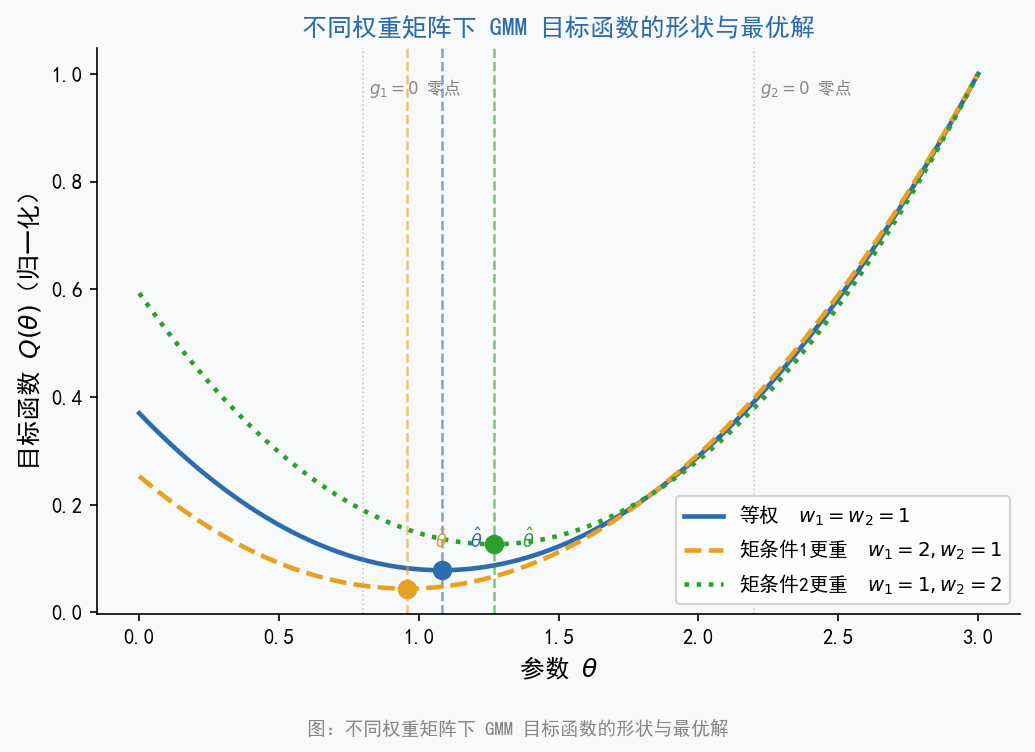

fig03 已保存


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_facecolor(COLOR_BG)
fig.patch.set_facecolor(COLOR_BG)

theta = np.linspace(0, 3, 500)

# 两个线性矩条件：零点分别在 theta=0.8 和 theta=2.2
a1, b1 = 2.0, 1.6    # g1 零点 = b1/a1 = 0.8
a2, b2 = 1.0, 2.2    # g2 零点 = b2/a2 = 2.2
g1 = a1 * theta - b1
g2 = a2 * theta - b2

# 三种权重
weight_configs = [
    (1.0, 1.0, COLOR_PRIMARY,   '等权  $w_1=w_2=1$',   '-',  2.2),
    (2.0, 1.0, COLOR_SECONDARY, '矩条件1更重  $w_1=2, w_2=1$', '--', 1.8),
    (1.0, 2.0, COLOR_GREEN,     '矩条件2更重  $w_1=1, w_2=2$', ':',  2.0),
]

opt_thetas = []
for w1, w2, color, label, ls, _ in weight_configs:
    Q = w1 * g1**2 + w2 * g2**2
    Q = Q / Q.max()          # 归一化便于对比
    ax.plot(theta, Q, color=color, lw=2.2, ls=ls, label=label)
    theta_opt = theta[np.argmin(Q)]
    opt_thetas.append((theta_opt, color))
    ax.axvline(theta_opt, color=color, lw=1.2, ls='--', alpha=0.6)
    ax.scatter([theta_opt], [Q.min()], color=color, s=70, zorder=5)

# 真实零点
for zpt, color in [(0.8, COLOR_PRIMARY+'88'), (2.2, COLOR_GREEN+'88')]:
    ax.axvline(zpt, color=COLOR_NEUTRAL, lw=0.8, ls=':', alpha=0.4)

# 标注
ax.text(0.82, 0.92, r'$g_1=0$ 零点', fontsize=8, color=COLOR_NEUTRAL,
        transform=ax.get_xaxis_transform(), ha='left')
ax.text(2.22, 0.92, r'$g_2=0$ 零点', fontsize=8, color=COLOR_NEUTRAL,
        transform=ax.get_xaxis_transform(), ha='left')

for theta_opt, color in opt_thetas:
    ax.annotate(f'  $\\hat{{\\theta}}$', xy=(theta_opt, 0.0), xytext=(theta_opt + 0.04, 0.12),
                fontsize=8.5, color=color)

ax.set_xlabel(r'参数 $\theta$', fontsize=12)
ax.set_ylabel(r'目标函数 $Q(\theta)$（归一化）', fontsize=12)
ax.set_title('不同权重矩阵下 GMM 目标函数的形状与最优解', fontsize=12,
             fontweight='bold', color=COLOR_PRIMARY)
ax.legend(fontsize=9.5, framealpha=0.85)
ax.spines[['top','right']].set_visible(False)

fig.text(0.5, 0.01, '图：不同权重矩阵下 GMM 目标函数的形状与最优解',
         ha='center', fontsize=9, color=COLOR_NEUTRAL)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('./figs/method_GMM_fig03_gmm_objective.png', dpi=300,
            bbox_inches='tight', facecolor=COLOR_BG)
plt.show()
print('fig03 已保存')

---
## Section 4：fig04 — 不同估计量的有限样本分布对比

> 本图用于第 6 节。通过 Monte Carlo 模拟（1000 次重复），展示在异方差场景下，2SLS、等权 GMM（$W=I$）、有效两步 GMM 三种估计量的有限样本分布，说明有效 GMM 方差最小、2SLS 方差最大。
>
> **对应讲义**：第 6 节「最优权重矩阵与有效性」

In [5]:
np.random.seed(2024)
N_MC   = 1000
n      = 200
beta   = 1.0
pi     = np.array([0.5, 0.4, 0.3])

betas_2sls  = []
betas_gmm_eq = []
betas_gmm_eff = []

for _ in range(N_MC):
    Z  = np.random.normal(0, 1, (n, 3))
    v  = np.random.normal(0, 1, n)
    x  = Z @ pi + v
    e  = np.random.normal(0, 1, n)
    sigma = 0.5 + 0.5 * np.abs(x)
    eps = sigma * e + 0.4 * v
    y   = beta * x + eps

    # ── 2SLS ────────────────────────────────────────────
    Pz     = Z @ np.linalg.solve(Z.T @ Z, Z.T)
    x_hat  = Pz @ x
    b_2sls = (x_hat @ y) / (x_hat @ x)
    betas_2sls.append(b_2sls)

    # ── 等权 GMM（W = I）──────────────────────────────────
    # g(β) = Z'(y - x·β)/n  →  解析解同 2SLS 但 W=I
    # 对线性情形：b = (X'Z W Z'X)^{-1} X'Z W Z'y，W=I
    XtZ = x.reshape(1,-1) @ Z          # (1,3)
    W_eq = np.eye(3)
    A    = float(XtZ @ W_eq @ XtZ.T)
    b_eq = float(XtZ @ W_eq @ (Z.T @ y)) / A
    betas_gmm_eq.append(b_eq)

    # ── 有效两步 GMM ─────────────────────────────────────
    # 第一步用 W=I 得初步残差
    eps1  = y - b_eq * x
    # 估计 S_hat（White 稳健）
    g_each = Z * eps1[:, None]         # (n,3)
    S_hat  = (g_each.T @ g_each) / n
    try:
        W_eff = np.linalg.inv(S_hat)
        A2    = float(XtZ @ W_eff @ XtZ.T)
        b_eff = float(XtZ @ W_eff @ (Z.T @ y)) / A2
    except np.linalg.LinAlgError:
        b_eff = b_eq
    betas_gmm_eff.append(b_eff)

betas_2sls    = np.array(betas_2sls)
betas_gmm_eq  = np.array(betas_gmm_eq)
betas_gmm_eff = np.array(betas_gmm_eff)

# ── 绘图 ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_facecolor(COLOR_BG)
fig.patch.set_facecolor(COLOR_BG)

xlim = (0.4, 1.6)
x_grid = np.linspace(*xlim, 300)

configs = [
    (betas_2sls,    COLOR_RED,       '2SLS'),
    (betas_gmm_eq,  COLOR_SECONDARY, '等权 GMM ($W=I$)'),
    (betas_gmm_eff, COLOR_PRIMARY,   '有效两步 GMM'),
]
for vals, color, name in configs:
    kde = stats.gaussian_kde(vals)
    ax.plot(x_grid, kde(x_grid), color=color, lw=2.5,
            label=f'{name}  Std={vals.std():.3f}')
    ax.fill_between(x_grid, kde(x_grid), alpha=0.08, color=color)

ax.axvline(beta, color='black', lw=2, ls='--', label=f'真实值 $\\beta={beta}$')

ax.set_xlabel(r'$\hat{\beta}$ 估计值', fontsize=12)
ax.set_ylabel('核密度估计（KDE）', fontsize=12)
ax.set_title('异方差场景下三种估计量的蒙特卡洛分布', fontsize=12,
             fontweight='bold', color=COLOR_PRIMARY)
ax.legend(fontsize=9.5, framealpha=0.85)
ax.set_xlim(*xlim)
ax.spines[['top','right']].set_visible(False)

fig.text(0.5, 0.01,
         f'图：异方差场景下三种估计量的蒙特卡洛分布（$n={n}$，{N_MC} 次重复）',
         ha='center', fontsize=9, color=COLOR_NEUTRAL)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('./figs/method_GMM_fig04_efficiency.png', dpi=300,
            bbox_inches='tight', facecolor=COLOR_BG)
plt.show()
print('fig04 已保存')
print(f'  2SLS Std       = {betas_2sls.std():.4f}')
print(f'  等权 GMM Std   = {betas_gmm_eq.std():.4f}')
print(f'  有效 GMM Std   = {betas_gmm_eff.std():.4f}')

TypeError: only 0-dimensional arrays can be converted to Python scalars

---
## Section 5：fig05 — 2SLS vs. GMM 权重机制对比示意图

> 本图用于第 4 节。直观展示 2SLS「等权合并工具变量」与有效 GMM「差异化加权矩条件」的本质差异。
>
> **对应讲义**：第 4 节「2SLS 与 GMM：提取信息 vs. 加权偏离」

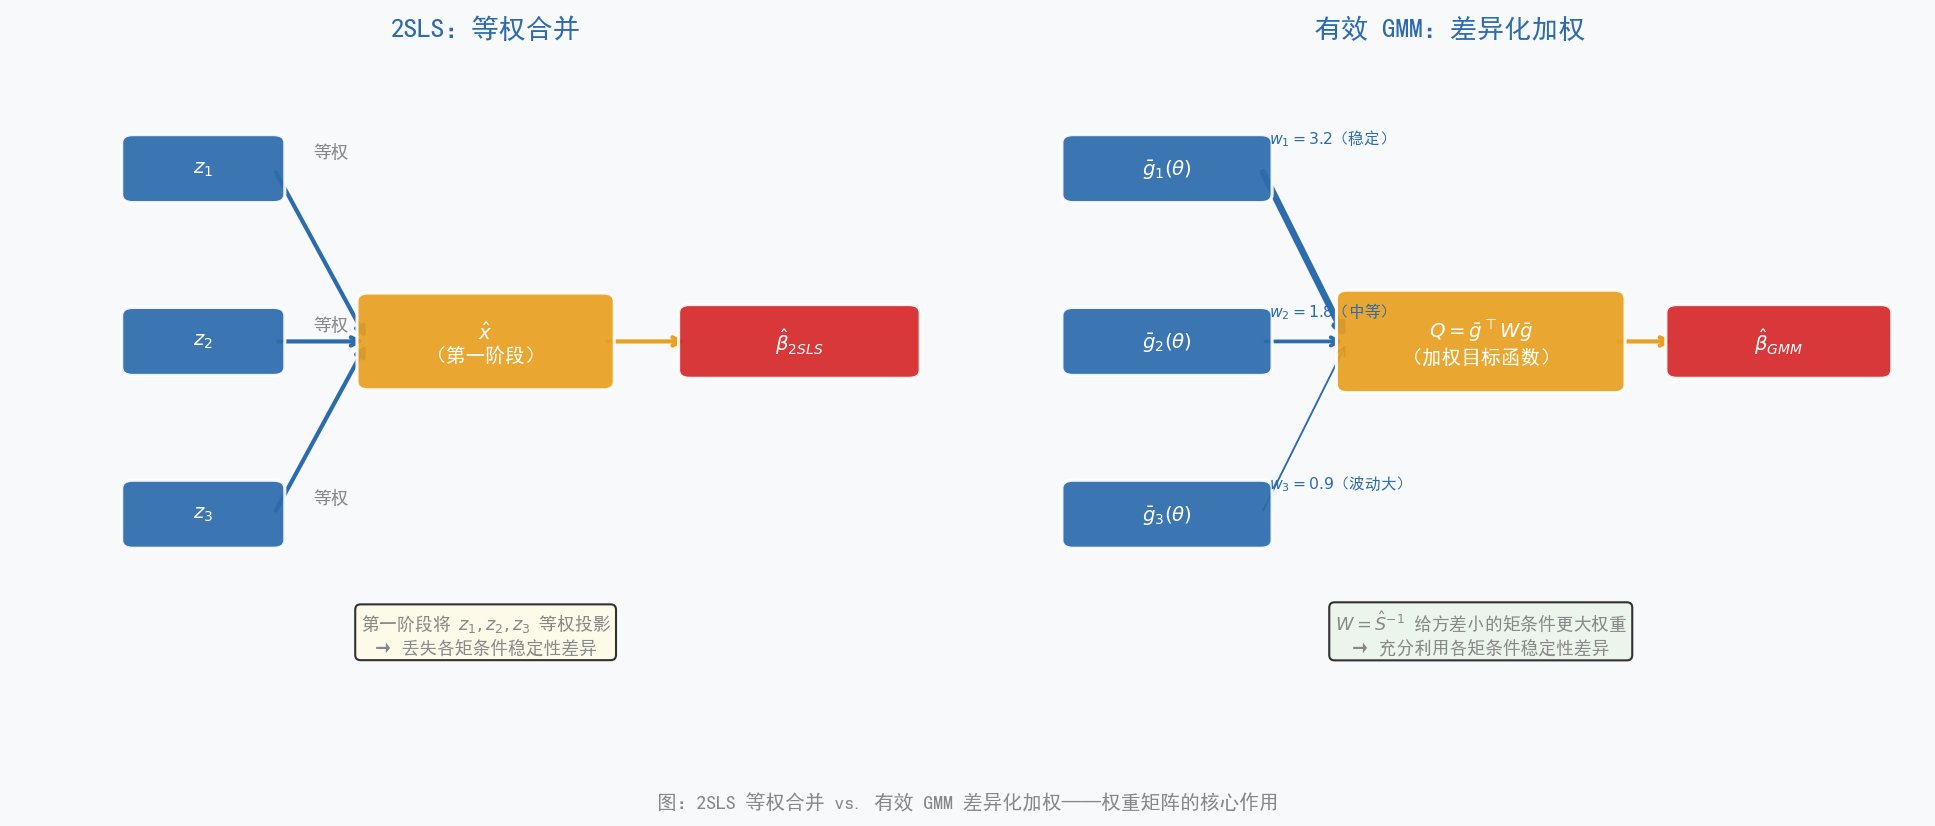

fig05 已保存


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor(COLOR_BG)

def draw_node(ax, x, y, text, color, width=1.6, height=0.55, fontsize=9.5):
    box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                         boxstyle='round,pad=0.07',
                         facecolor=color, edgecolor='white',
                         linewidth=1.5, alpha=0.92, zorder=3)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', color='white',
            fontsize=fontsize, fontweight='bold', zorder=4)

def draw_arrow(ax, x1, y1, x2, y2, lw=1.5, color=COLOR_NEUTRAL, label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw), zorder=2)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.08, my, label, fontsize=8, color=color, va='center')

# ── 左图：2SLS 等权合并 ──────────────────────────────────
ax = axes[0]
ax.set_facecolor(COLOR_BG)
ax.set_xlim(0, 6); ax.set_ylim(0, 6); ax.axis('off')
ax.set_title('2SLS：等权合并', fontsize=13, fontweight='bold',
             color=COLOR_PRIMARY, pad=8)

# 工具变量节点
z_positions = [(1.2, 5.0), (1.2, 3.5), (1.2, 2.0)]
z_labels = ['$z_1$', '$z_2$', '$z_3$']
for (xz, yz), lbl in zip(z_positions, z_labels):
    draw_node(ax, xz, yz, lbl, COLOR_PRIMARY, width=0.9, height=0.45)

# 第一阶段拟合值节点
draw_node(ax, 3.0, 3.5, '$\\hat{x}$\n（第一阶段）', COLOR_SECONDARY, width=1.5, height=0.7)

# 最终估计量节点
draw_node(ax, 5.0, 3.5, '$\\hat{\\beta}_{2SLS}$', COLOR_RED, width=1.4, height=0.5)

# 等权箭头（粗细相同）
for xz, yz in z_positions:
    draw_arrow(ax, xz+0.45, yz, 2.25, 3.5, lw=2.0, color=COLOR_PRIMARY)

# 等权标注
ax.text(1.9, 5.1, '等权', fontsize=8.5, color=COLOR_NEUTRAL, style='italic')
ax.text(1.9, 3.6, '等权', fontsize=8.5, color=COLOR_NEUTRAL, style='italic')
ax.text(1.9, 2.1, '等权', fontsize=8.5, color=COLOR_NEUTRAL, style='italic')

draw_arrow(ax, 3.75, 3.5, 4.3, 3.5, lw=2.0, color=COLOR_SECONDARY)

ax.text(3.0, 0.8, '第一阶段将 $z_1, z_2, z_3$ 等权投影\n→ 丢失各矩条件稳定性差异',
        ha='center', fontsize=8.5, color=COLOR_NEUTRAL,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFFBE6', alpha=0.8))

# ── 右图：有效 GMM 差异化加权 ────────────────────────────
ax = axes[1]
ax.set_facecolor(COLOR_BG)
ax.set_xlim(0, 6); ax.set_ylim(0, 6); ax.axis('off')
ax.set_title('有效 GMM：差异化加权', fontsize=13, fontweight='bold',
             color=COLOR_PRIMARY, pad=8)

# 矩条件节点
g_positions = [(1.2, 5.0), (1.2, 3.5), (1.2, 2.0)]
g_labels = ['$\\bar{g}_1(\\theta)$', '$\\bar{g}_2(\\theta)$', '$\\bar{g}_3(\\theta)$']
for (xg, yg), lbl in zip(g_positions, g_labels):
    draw_node(ax, xg, yg, lbl, COLOR_PRIMARY, width=1.2, height=0.45)

# 目标函数节点
draw_node(ax, 3.2, 3.5, '$Q=\\bar{g}^\\top W\\bar{g}$\n（加权目标函数）',
          COLOR_SECONDARY, width=1.7, height=0.75)

# 最终估计量节点
draw_node(ax, 5.1, 3.5, '$\\hat{\\beta}_{GMM}$', COLOR_RED, width=1.3, height=0.5)

# 差异化粗细箭头
arrow_weights = [3.2, 1.8, 0.9]   # g1最稳定→最大权重
w_labels = ['$w_1=3.2$（稳定）', '$w_2=1.8$（中等）', '$w_3=0.9$（波动大）']
for i, ((xg, yg), lw_val, wlbl) in enumerate(zip(g_positions, arrow_weights, w_labels)):
    draw_arrow(ax, xg+0.6, yg, 2.35, 3.5, lw=lw_val, color=COLOR_PRIMARY)
    ax.text(1.85, yg + 0.22, wlbl, fontsize=7.5, color=COLOR_PRIMARY, style='italic')

draw_arrow(ax, 4.05, 3.5, 4.45, 3.5, lw=2.0, color=COLOR_SECONDARY)

ax.text(3.2, 0.8, '$W = \\hat{S}^{-1}$ 给方差小的矩条件更大权重\n→ 充分利用各矩条件稳定性差异',
        ha='center', fontsize=8.5, color=COLOR_NEUTRAL,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', alpha=0.8))

fig.text(0.5, 0.01, '图：2SLS 等权合并 vs. 有效 GMM 差异化加权——权重矩阵的核心作用',
         ha='center', fontsize=9.5, color=COLOR_NEUTRAL)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('./figs/method_GMM_fig05_2sls_vs_gmm.png', dpi=300,
            bbox_inches='tight', facecolor=COLOR_BG)
plt.show()
print('fig05 已保存')

---
## Section 7：生成模拟数据（data01–data04）

以下各小节生成 `GMM_case.ipynb` 所需的四个模拟数据集，保存到 `./data/`。

### 数据 01：`method_GMM_data01_iv_hetero.csv`

> **数据说明**：过度识别 IV 回归的模拟数据，含异方差误差。用于 Case 1：展示有效 GMM vs. 2SLS 的差异。  
> **DGP**：$y_i = 1 + 1.5 x_i + \varepsilon_i$，$x_i$ 内生（与 $\varepsilon_i$ 相关），四个工具变量 $z_1, z_2, z_3, z_4$，误差项异方差 $\sigma_i = 0.5 + 0.5|x_i|$  
> **后续用途**：`GMM_case.ipynb` Case 1

In [8]:
np.random.seed(2024)
n = 500

z1 = np.random.normal(0, 1, n)
z2 = np.random.normal(0, 1, n)
z3 = np.random.normal(0, 1, n)
z4 = np.random.normal(0, 1, n)  # 第四个工具变量（更弱）

v  = np.random.normal(0, 1, n)
x  = 0.5*z1 + 0.4*z2 + 0.3*z3 + 0.15*z4 + v

e     = np.random.normal(0, 1, n)
sigma = 0.5 + 0.5*np.abs(x)
eps   = sigma * e + 0.4*v   # 与 x（通过 v）相关，制造内生性

y = 1 + 1.5*x + eps

df1 = pd.DataFrame({'y': y, 'x': x, 'z1': z1, 'z2': z2, 'z3': z3, 'z4': z4})
df1.to_csv('./data/method_GMM_data01_iv_hetero.csv', index=False)
print(f'数据01已保存，形状：{df1.shape}')
print(f'真实参数：截距=1, 斜率=1.5')
print(df1.describe().round(3))

数据01已保存，形状：(500, 6)
真实参数：截距=1, 斜率=1.5
             y        x       z1       z2       z3       z4
count  500.000  500.000  500.000  500.000  500.000  500.000
mean     1.113    0.043   -0.026    0.074   -0.050   -0.015
std      2.514    1.270    1.058    0.969    1.016    1.035
min     -7.392   -3.247   -3.421   -3.673   -2.904   -2.668
25%     -0.449   -0.843   -0.714   -0.572   -0.797   -0.704
50%      1.104    0.023   -0.046    0.063   -0.032   -0.007
75%      2.476    0.907    0.664    0.762    0.583    0.737
max      9.182    3.169    3.576    2.556    4.402    2.770


### 数据 02：`method_GMM_data02_euler_simulated.csv`

> **数据说明**：CRRA 效用函数 Euler 方程的模拟数据。DGP 直接从 Euler 方程反推，参数真值已知，便于验证 GMM 估计结果。  
> **DGP 参数**：$\beta = 0.98$（主观贴现因子），$\gamma = 2.0$（相对风险厌恶系数）  
> **矩条件**：$E[\beta(c_{t+1}/c_t)^{-\gamma} R_{t+1} - 1 \mid z_t] = 0$  
> **后续用途**：`GMM_case.ipynb` Case 2a

In [9]:
np.random.seed(2024)
T = 200

beta_true  = 0.98
gamma_true = 2.0

log_dc = np.random.normal(0.005, 0.02, T)
dc     = np.exp(log_dc)

R_mean = 1 / (beta_true * dc**(-gamma_true))
R      = R_mean * np.exp(np.random.normal(0, 0.05, T))

dc_lag1 = np.roll(dc, 1); dc_lag1[0] = np.nan
dc_lag2 = np.roll(dc, 2); dc_lag2[:2] = np.nan
R_lag1  = np.roll(R, 1);  R_lag1[0]  = np.nan
R_lag2  = np.roll(R, 2);  R_lag2[:2] = np.nan

df2 = pd.DataFrame({'dc': dc, 'R': R,
                    'dc_lag1': dc_lag1, 'dc_lag2': dc_lag2,
                    'R_lag1':  R_lag1,  'R_lag2':  R_lag2})
df2 = df2.dropna().reset_index(drop=True)
df2.to_csv('./data/method_GMM_data02_euler_simulated.csv', index=False)
print(f'数据02已保存，形状：{df2.shape}')
print(f'真实参数：beta={beta_true}, gamma={gamma_true}')
print(df2.describe().round(4))

数据02已保存，形状：(198, 6)
真实参数：beta=0.98, gamma=2.0
             dc         R   dc_lag1   dc_lag2    R_lag1    R_lag2
count  198.0000  198.0000  198.0000  198.0000  198.0000  198.0000
mean     1.0061    1.0270    1.0064    1.0067    1.0282    1.0289
std      0.0204    0.0670    0.0201    0.0202    0.0675    0.0682
min      0.9537    0.8275    0.9537    0.9537    0.8275    0.8275
25%      0.9937    0.9813    0.9941    0.9941    0.9850    0.9850
50%      1.0058    1.0239    1.0060    1.0061    1.0245    1.0251
75%      1.0200    1.0695    1.0202    1.0211    1.0709    1.0713
max      1.0608    1.1830    1.0608    1.0608    1.1830    1.1830


### 数据 03：`method_GMM_data03_asset_pricing.csv`

> **数据说明**：横截面资产定价检验的模拟数据，模拟 $N=25$ 个资产组合在 $T=60$ 期上的收益率面板，以及单一因子（市场超额收益）。  
> **DGP**：$R_{i,t} - R_f = \alpha_i + \beta_i (R_{m,t} - R_f) + \varepsilon_{i,t}$，定价误差 $\alpha_i \approx 0$，$\varepsilon_{i,t}$ 之间允许截面相关  
> **后续用途**：`GMM_case.ipynb` Case 3（可选）

In [10]:
np.random.seed(2024)
N = 25
T = 60

mkt_excess = np.random.normal(0.006, 0.04, T)
betas_true = np.linspace(0.5, 1.5, N)

cov_matrix = np.ones((N, N)) * 0.3 + np.eye(N) * 0.7
cov_matrix *= 0.02**2
eps_panel = np.random.multivariate_normal(np.zeros(N), cov_matrix, T)

excess_returns = np.zeros((T, N))
for i in range(N):
    alpha_i = 0.001 * np.random.randn()
    excess_returns[:, i] = alpha_i + betas_true[i] * mkt_excess + eps_panel[:, i]

rows = []
for t in range(T):
    for i in range(N):
        rows.append({'time': t, 'asset': i,
                     'excess_ret': excess_returns[t, i],
                     'mkt_excess': mkt_excess[t],
                     'beta_true': betas_true[i]})
df3 = pd.DataFrame(rows)
df3.to_csv('./data/method_GMM_data03_asset_pricing.csv', index=False)
print(f'数据03已保存，形状：{df3.shape}')
print(f'资产数：{N}，时间期数：{T}')
print(df3.head(6).round(4))

数据03已保存，形状：(1500, 5)
资产数：25，时间期数：60
   time  asset  excess_ret  mkt_excess  beta_true
0     0      0      0.0295      0.0727     0.5000
1     0      1      0.0215      0.0727     0.5417
2     0      2      0.0491      0.0727     0.5833
3     0      3      0.0543      0.0727     0.6250
4     0      4      0.0330      0.0727     0.6667
5     0      5      0.0516      0.0727     0.7083


### 数据 04：`method_GMM_data04_euler_FRED.csv`（FRED 真实数据备份）

> **数据说明**：从 FRED 下载的美国季度消费增长率和股票市场收益率数据，用于 Case 2b（真实数据版 Euler 方程 GMM）。  
> **数据来源**：FRED（美联储圣路易斯经济数据库）  
> **样本期**：1960Q1–2019Q4（约 240 个季度）  
> **后续用途**：`GMM_case.ipynb` Case 2b（可选模块）  
>
> ⚠️ 此数据集需要网络连接，若下载失败会给出清晰提示，Case 2b 可使用本地备份或 data02 代替。

In [12]:
!pip install fredapi

In [14]:
from fredapi import Fred

# 免费注册获取 key：https://fred.stlouisfed.org/docs/api/api_key.html
# 用邮箱注册一个新账号 -> 右击右上角个人头像 -> API Keys -> Create a new API key -> 复制生成的 key 填入下面
fred = Fred(api_key='e77d63984aa9d595c3ffd02254f8c079')

start, end = '1960-01-01', '2019-12-31'

def fetch_series_with_fallback(candidates, col_name):
	last_err = None
	for sid in candidates:
		try:
			s = fred.get_series(
				sid,
				observation_start=start,
				observation_end=end
			)
			s = s.dropna().to_frame(col_name)
			print(f'使用序列 {sid} -> {col_name}')
			return s
		except Exception as e:
			last_err = e
	raise ValueError(f'以下序列均不可用: {candidates}; 最后错误: {last_err}')

# 消费增长：先尝试原始增长率序列；若不可用则退回到水平序列并自行计算增长率
pce = fetch_series_with_fallback(['DPCERAS1Q086SBEA', 'PCECC96'], 'pce_raw')
pce.index = pd.to_datetime(pce.index)
pce = pce.resample('Q').last()
if pce['pce_raw'].abs().max() > 5:   # 通常表示水平值而非增长率
	pce['pce_growth'] = pce['pce_raw'].pct_change()
else:
	pce['pce_growth'] = pce['pce_raw']
pce = pce[['pce_growth']].dropna()

# 股市收益：取 SP500 水平后转季度收益率
sp500 = fetch_series_with_fallback(['SP500'], 'sp500_level')
sp500.index = pd.to_datetime(sp500.index)
sp500 = sp500.resample('Q').last().pct_change().dropna()
sp500.columns = ['sp500_ret']

# 无风险利率：TB3MS（百分比年化）转季度小数利率
tbill = fetch_series_with_fallback(['TB3MS'], 'rf')
tbill.index = pd.to_datetime(tbill.index)
tbill = tbill.resample('Q').last() / 400

df4 = pd.concat([pce, sp500, tbill], axis=1).dropna()
df4['excess_ret'] = df4['sp500_ret'] - df4['rf']
df4 = df4.reset_index()
df4.to_csv('./data/method_GMM_data04_euler_FRED.csv', index=False)
print(f'✓ FRED 数据下载成功，形状：{df4.shape}')
print(df4.describe().round(4))

ValueError: 以下序列均不可用: ['DPCERAS1Q086SBEA', 'PCECC96']; 最后错误: <urlopen error [WinError 10054] 远程主机强迫关闭了一个现有的连接。>

In [11]:
try:
    import pandas_datareader.data as web
    from datetime import datetime

    start = datetime(1960, 1, 1)
    end   = datetime(2019, 12, 31)

    pce = web.DataReader('DPCERAS1Q086SBEA', 'fred', start, end)
    pce.columns = ['pce_growth']
    pce.index = pd.to_datetime(pce.index)
    pce = pce.resample('Q').last()

    sp500 = web.DataReader('SP500', 'fred', start, end)
    sp500 = sp500.resample('Q').last().pct_change().dropna()
    sp500.columns = ['sp500_ret']

    tbill = web.DataReader('TB3MS', 'fred', start, end)
    tbill = tbill.resample('Q').last() / 400
    tbill.columns = ['rf']

    df4 = pd.concat([pce, sp500, tbill], axis=1).dropna()
    df4['excess_ret'] = df4['sp500_ret'] - df4['rf']
    df4 = df4.reset_index()
    df4.to_csv('./data/method_GMM_data04_euler_FRED.csv', index=False)
    print(f'✓ FRED 数据下载成功，形状：{df4.shape}')
    print(df4.describe().round(4))

except Exception as e:
    print(f'✗ FRED 数据下载失败：{e}')
    print('  → 请手动提供 ./data/method_GMM_data04_euler_FRED.csv')
    print('  → 或在 Case 2b 中直接使用 data02（模拟数据）代替')

✗ FRED 数据下载失败：No module named 'pandas_datareader'
  → 请手动提供 ./data/method_GMM_data04_euler_FRED.csv
  → 或在 Case 2b 中直接使用 data02（模拟数据）代替


---
## 汇总

运行完所有 Cell 后，以下文件应已生成：

| 文件 | 用途 |
|:----|:----|
| `./figs/method_GMM_fig01_flowchart.png` | GMM 总流程图（导言、第10节）|
| `./figs/method_GMM_fig02_moment_conditions.png` | 恰好识别 vs. 过度识别（第2节）|
| `./figs/method_GMM_fig03_gmm_objective.png` | 目标函数与权重矩阵（第3节）|
| `./figs/method_GMM_fig04_efficiency.png` | 蒙特卡洛分布对比（第6节）|
| `./figs/method_GMM_fig05_2sls_vs_gmm.png` | 权重机制示意图（第4节）|
| `./data/method_GMM_data01_iv_hetero.csv` | Case 1 数据（过度识别 IV + 异方差）|
| `./data/method_GMM_data02_euler_simulated.csv` | Case 2a 数据（Euler 方程模拟）|
| `./data/method_GMM_data03_asset_pricing.csv` | Case 3 数据（资产定价检验）|
| `./data/method_GMM_data04_euler_FRED.csv` | Case 2b 数据（FRED 真实数据，需网络）|